# Assignment 2 - Hugging Face transformers for FactNews

This notebook builds and evaluates **traditional machine learning** classifiers for the **FactNews** dataset, a Brazilian Portuguese sentence-level dataset for factuality and media-bias analysis.

This project was developed by Elton Tamele (up201908676@up.pt), Maureen Ah-shú (up201708043@up.pt), and Tomás Teixeira (up202208041@up.pt) for the Natural Language Processing course in MEIC, FEUP.

## Goals
..

## Classification tasks
This notebook works with the two formulations exposed by the **FactNews** repository:

- **Task A** - 3-class sentence classification
  - Labels: biased, factual, quote
- **Task B** - binary factuality design classification  
  - Labels: factual, non_factual

## Dataset provenance

According to the **FactNews** repository and the accompanying RANLP 2023 paper, the dataset:
- is in **Brazilian Portuguese**
- contains **6,191 annotated sentences**
- comes from **300 news documents** covering **100 news stories**
- uses three media outlets: **Folha de São Paulo**, **Estadão**, and **O Globo**
- covers domains such as **politics, world, sports, daily, culture, and science**
- includes sentence-level annotations for:
  - **factual spans** as 0
  - **biased spans** as 1
  - **quotes** as -1

The original paper reports the following strong baselines:
- **Sentence-level factuality prediction**: **F1 = 0.88** with fine-tuned BERT
- **Sentence-level media bias prediction**: **F1 = 0.67** with fine-tuned BERT

Since this assignment forbids deep learning architectures such as Transformers, those values are used **only as contextual reference**, not as target models.

### References
- Repository: [franciellevargas/FactNews](https://github.com/franciellevargas/FactNews)
- Paper: *Predicting Sentence-Level Factuality of News and Bias of Media Outlets* (RANLP 2023)

## Environment Preparation

In [1]:
!pip install -U torch torchvision torchaudio
!pip install -U datasets transformers accelerate

In [2]:
!pip install -q \
    "datasets>=3.0.0" \
    "transformers>=4.44.0" \
    "accelerate>=0.34.0" \
    pandas numpy matplotlib scikit-learn nltk gensim wordcloud imbalanced-learn

In [4]:
 # If needed, uncomment the next line to install dependencies.
%pip install pandas==2.2.2 numpy==2.0.2 matplotlib scikit-learn nltk gensim wordcloud imbalanced-learn -q
!pip install transformers datasets accelerate -q

import re
import warnings
import nltk
nltk.download('stopwords')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from scipy.sparse import hstack, csr_matrix
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (classification_report,accuracy_score,f1_score,confusion_matrix)
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_sample_weight
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import resample

from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
import torch
import gc

import pickle
from google.colab import drive
drive.mount('/content/drive')



SAVE_DIR = "/content/drive/MyDrive/pln_results/"
import os; os.makedirs(SAVE_DIR, exist_ok=True)

plt.rcParams["figure.figsize"] = (10, 5)

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load Data

In [5]:
!wget -q "https://raw.githubusercontent.com/tomast100/PLN_Project_Data/master/factnews_dataset.csv"
!wget -q "https://raw.githubusercontent.com/tomast100/PLN_Project_Data/master/factnews_dataset_factuality_design.csv"

df_main = pd.read_csv("factnews_dataset.csv")
df_fact = pd.read_csv("factnews_dataset_factuality_design.csv")

print("Main dataset shape:", df_main.shape)
print("Factuality-design dataset shape:", df_fact.shape)

Main dataset shape: (6191, 7)
Factuality-design dataset shape: (6191, 7)


### Column description

From inspection, both files have the same schema:

- `file`: original document identifier
- `id_sente`: sentence identifier
- `id_article`: article/story identifier
- `domain`: news domain
- `year`: publication year
- `sentences`: sentence text
- `classe`: label

The difference is in the meaning of `classe`:
- in the **main dataset** it encodes the 3-way annotation
- in the **factuality design dataset** it encodes the binary factuality design

## Pre-processing

The preprocessing used in this notebook is intentionally simple and easy to justify:

- lowercase
- remove URLs
- remove digits
- remove punctuation/special symbols
- normalize whitespace

This is a reasonable baseline for short news sentences in Portuguese.  
We avoid aggressive stemming/lemmatization here because:
1. the dataset is not extremely large,
2. some wording choices may carry bias cues,
3. simple normalization makes it easier to interpret model errors.

In [6]:
import re

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = text.replace("“", '"').replace("”", '"').replace("‘", "'").replace("’", "'")
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^\w\sÀ-ÿ\"']", " ", text)
    text = re.sub(r"_", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


for frame in (df_main, df_fact):
    frame["text_clean"] = frame["sentences"].apply(clean_text)
    frame["n_chars"] = frame["sentences"].astype(str).str.len()
    frame["n_words"] = frame["text_clean"].str.split().str.len()
    frame["n_double_quotes"] = (frame["sentences"].astype(str).str.replace("“", '"', regex=False).str.replace("”", '"', regex=False).str.count('"'))
    frame["n_single_quotes"] = (frame["sentences"].astype(str).str.replace("‘", "'", regex=False).str.replace("’", "'", regex=False).str.count("'"))
    frame["has_quotes"] = ((frame["n_double_quotes"] + frame["n_single_quotes"]) > 0).astype(int)

main_label_map = {-1: "quote", 0: "factual", 1: "biased"}
fact_label_map = {0: "factual", 1: "non_factual"}

df_main["label"] = df_main["classe"].map(main_label_map)
df_fact["label"] = df_fact["classe"].map(fact_label_map)

display(
    df_main[
        ["sentences", "text_clean", "label", "has_quotes"]
    ].head()
)

,sentences,text_clean,label,has_quotes
0,"""Não houve sobreviventes"", disse Okala.","""não houve sobreviventes"" disse okala",quote,1
1,As vítimas do acidente foram 14 passageiros e ...,as vítimas do acidente foram passageiros e trê...,factual,0
2,"O avião explodiu e se incendiou, acrescentou o...",o avião explodiu e se incendiou acrescentou o ...,factual,0
3,"O porta-voz informou que o avião, um Soviet An...",o porta voz informou que o avião um soviet ant...,factual,0
4,"Segundo fontes aeroportuárias, os membros da t...",segundo fontes aeroportuárias os membros da tr...,factual,0


## Exploratory Data Analysis

In [6]:
print("Task A - Main label distribution:")
display(df_main["label"].value_counts().rename_axis("label").reset_index(name="count"))

print("Task B - Binary factuality label distribution:")
display(df_fact["label"].value_counts().rename_axis("label").reset_index(name="count"))

Task A - Main label distribution:


,label,count
0,factual,4242
1,quote,1391
2,biased,558


Task B - Binary factuality label distribution:


,label,count
0,factual,4242
1,non_factual,1949


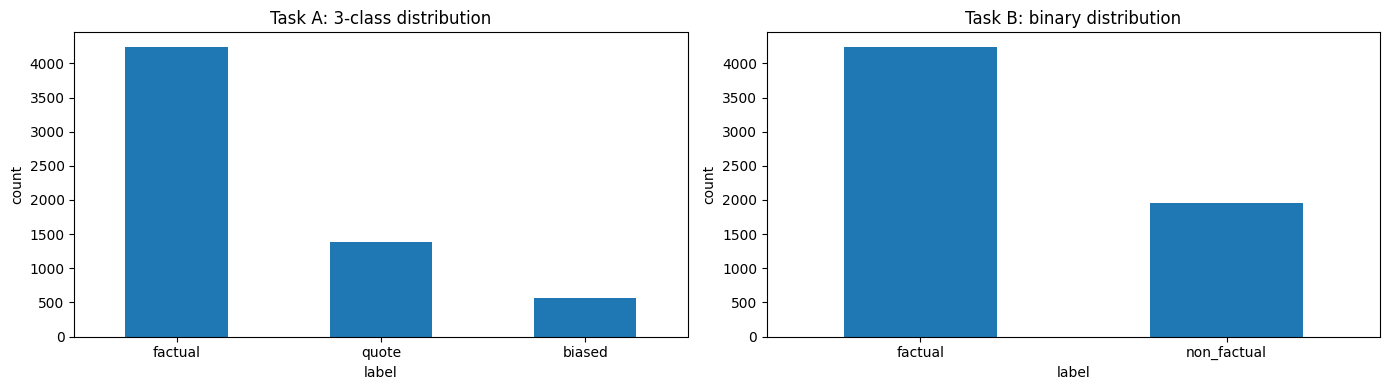

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_main["label"].value_counts().plot(kind="bar", ax=axes[0], title="Task A: 3-class distribution")
axes[0].set_xlabel("label")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=0)

df_fact["label"].value_counts().plot(kind="bar", ax=axes[1], title="Task B: binary distribution")
axes[1].set_xlabel("label")
axes[1].set_ylabel("count")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## Data Preparation

In [7]:
label_map = {-1: "quote", 0: "factual", 1: "biased"}
id2label  = {0: "biased", 1: "factual", 2: "quote"}
label2id  = {"biased": 0, "factual": 1, "quote": 2}

df_main["label"] = df_main["classe"].map(label_map)
df_main["label_id"] = df_main["label"].map(label2id)


In [8]:
train_df, test_df = train_test_split(
    df_main, test_size=0.2, random_state=42, stratify=df_main["label_id"]
)

## Free memory function

In [9]:
TARGET_NAMES = ["biased", "factual", "quote"]

def free_memory(*models):
    for m in models:
        del m
    gc.collect()
    torch.cuda.empty_cache()
    print(f"VRAM free: {torch.cuda.mem_get_info()[0] / 1e9:.2f} GB")


def save_results(name, y_true, y_pred):
    data = {"y_true": y_true, "y_pred": y_pred}
    with open(f"{SAVE_DIR}{name.replace(' ', '_')}.pkl", "wb") as f:
        pickle.dump(data, f)
    print(f"Saved: {name}")

## Hugging Face Transformers

[Hugging Face](https://huggingface.co) is an open-source platform that provides
a central hub for sharing pre-trained machine learning models and datasets.
Its core library, `transformers`, offers a unified API to load, fine-tune, and
evaluate thousands of pre-trained models for Natural Language Processing tasks.

To select appropriate models for this task, we searched the Hugging Face Hub
for models compatible with Brazilian Portuguese and suitable for sequence
classification. This led us to the following two models, which will be
evaluated and compared throughout this notebook:

- **mBERT** (`google-bert/bert-base-multilingual-cased`): a multilingual BERT
  model pre-trained on Wikipedia across 104 languages, including Portuguese.
- **BERTimbau** (`neuralmind/bert-base-portuguese-cased`): a BERT model
  pre-trained exclusively on Brazilian Portuguese data (BrWaC corpus).

Each model is explored in detail in the sections below.

**Imbalaced**

Como um dos nossos principais problemas na última entrega foi conseguir mitigar os problemas que o desblanceamento do dataset nos causou, decidimos testar mais técnicas para lidar com este problema. Essas técnicas testadas foram as seguintes:

- Without resampling: Já presente na última entrega
- Manual Oversampling: Já presente na última entrega
- Class weight in loss: Já presente na última entrega
-

### mBert


**mBERT** (`google-bert/bert-base-multilingual-cased`) is a multilingual
version of BERT (Bidirectional Encoder Representations from Transformers),
introduced by Devlin et al. (2019). It was pre-trained on Wikipedia text
from 104 languages simultaneously, including Portuguese, using Masked
Language Modelling (MLM) and Next Sentence Prediction (NSP).

Despite not being specifically designed for Portuguese, mBERT serves as a
strong multilingual baseline for NLP tasks across many languages. It contains
**179M parameters** and uses a cased WordPiece tokenizer shared across all
104 languages.

In [31]:
results = {}

MODEL_NAME = "google-bert/bert-base-multilingual-cased"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["sentences"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

# Converter para HuggingFace Dataset
train_ds = Dataset.from_pandas(train_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"}))
test_ds  = Dataset.from_pandas(test_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"}))

train_ds = train_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds.set_format("torch",  columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/4952 [00:00<?, ? examples/s]

Map:   0%|          | 0/1239 [00:00<?, ? examples/s]

In [34]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.

In [12]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted")
    }

### Without resampling

In [35]:
training_args = TrainingArguments(
    output_dir="./mbert_factnews",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    fp16=True,          # GPU no Colab — acelera o treino
    seed=42,
    logging_steps=50,
    report_to="none"    # desativa wandb
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

In [15]:
trainer.train()

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted
1,0.331440,0.337973,0.685978,0.846781
2,0.245955,0.354594,0.744441,0.876837
3,0.186122,0.407446,0.780494,0.890285


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=930, training_loss=0.28113898513137653, metrics={'train_runtime': 220.5315, 'train_samples_per_second': 67.365, 'train_steps_per_second': 4.217, 'total_flos': 977203233441792.0, 'train_loss': 0.28113898513137653, 'epoch': 3.0})

In [16]:
TARGET_NAMES = ["biased", "factual", "quote"]

preds_output = trainer.predict(test_ds)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = test_df["label_id"].values


print(classification_report(y_true, y_pred, target_names=TARGET_NAMES))


save_results("mBERT - Base", y_true, y_pred)


free_memory(model)

              precision    recall  f1-score   support

      biased       0.62      0.40      0.49       112
     factual       0.91      0.96      0.93       849
       quote       0.93      0.91      0.92       278

    accuracy                           0.90      1239
   macro avg       0.82      0.76      0.78      1239
weighted avg       0.89      0.90      0.89      1239

Saved: mBERT - Base
VRAM free: 12.66 GB


#### Manual Oversampling

In [17]:
train_biased  = train_df[train_df["label_id"] == 0]
train_factual = train_df[train_df["label_id"] == 1]
train_quote   = train_df[train_df["label_id"] == 2]

train_biased_up = resample(train_biased, replace=True,
                           n_samples=len(train_factual), random_state=42)
train_quote_up  = resample(train_quote,  replace=True,
                           n_samples=len(train_factual), random_state=42)

train_balanced = pd.concat([train_factual, train_biased_up, train_quote_up])
train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)



train_ds_os = Dataset.from_pandas(
    train_balanced[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)
train_ds_os = train_ds_os.map(tokenize, batched=True)
train_ds_os.set_format("torch", columns=["input_ids", "attention_mask", "labels"])



model_os = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id
)

trainer_os = Trainer(
    model=model_os,
    args=training_args,
    train_dataset=train_ds_os,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

print("=== Variation 2: Oversampling ===")
trainer_os.train()


preds_os = trainer_os.predict(test_ds)
y_pred_os = np.argmax(preds_os.predictions, axis=-1)
print(classification_report(test_df["label_id"].values, y_pred_os,
      target_names=["biased", "factual", "quote"]))


preds_output = trainer.predict(test_ds)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = test_df["label_id"].values


print(classification_report(y_true, y_pred, target_names=TARGET_NAMES))


save_results("mBERT - Oversampling", y_true, y_pred)


free_memory(model_os)

Map:   0%|          | 0/10179 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.

=== Variation 2: Oversampling ===


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted
1,0.240959,0.441658,0.764825,0.870246
2,0.093485,0.610907,0.772969,0.881580
3,0.025718,0.692153,0.782649,0.885326


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

              precision    recall  f1-score   support

      biased       0.58      0.46      0.51       112
     factual       0.91      0.95      0.93       849
       quote       0.93      0.89      0.91       278

    accuracy                           0.89      1239
   macro avg       0.81      0.76      0.78      1239
weighted avg       0.88      0.89      0.89      1239



              precision    recall  f1-score   support

      biased       0.62      0.40      0.49       112
     factual       0.91      0.96      0.93       849
       quote       0.93      0.91      0.92       278

    accuracy                           0.90      1239
   macro avg       0.82      0.76      0.78      1239
weighted avg       0.89      0.90      0.89      1239

Saved: mBERT - Oversampling
VRAM free: 10.74 GB


#### Class weights in loss

In [36]:
weights = compute_class_weight("balanced",
                               classes=np.array([0, 1, 2]),
                               y=train_df["label_id"].values)
class_weights = torch.tensor(weights, dtype=torch.float)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(
            weight=class_weights.to(outputs.logits.device)
        )(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

model_cw = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id
)

trainer_cw = WeightedTrainer(
    model=model_cw,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

print("=== Variation 3: Class Weights ===")
trainer_cw.train()

preds_cw = trainer_cw.predict(test_ds)
y_pred_cw = np.argmax(preds_cw.predictions, axis=-1)
print(classification_report(test_df["label_id"].values, y_pred_cw,
      target_names=["biased", "factual", "quote"]))



preds_output = trainer.predict(test_ds)
y_true = test_df["label_id"].values


print(classification_report(y_true, y_pred_cw, target_names=TARGET_NAMES))


save_results("mBERT - Class weight in loss", y_true, y_pred_cw)


free_memory(model_cw)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.

=== Variation 3: Class Weights ===


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted
1,0.491932,0.513246,0.765915,0.861615
2,0.388163,0.606246,0.801254,0.892140
3,0.281913,0.717694,0.801313,0.890292


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

              precision    recall  f1-score   support

      biased       0.60      0.54      0.57       112
     factual       0.92      0.93      0.93       849
       quote       0.90      0.91      0.90       278

    accuracy                           0.89      1239
   macro avg       0.81      0.79      0.80      1239
weighted avg       0.89      0.89      0.89      1239



              precision    recall  f1-score   support

      biased       0.60      0.54      0.57       112
     factual       0.92      0.93      0.93       849
       quote       0.90      0.91      0.90       278

    accuracy                           0.89      1239
   macro avg       0.81      0.79      0.80      1239
weighted avg       0.89      0.89      0.89      1239

Saved: mBERT - Class weight in loss
VRAM free: 6.60 GB


### BERTimbau

#### Without Sampling

In [19]:
# ── BERTimbau ────────────────────────────────────────────────────────────────
BERTIMBAU_NAME = "neuralmind/bert-base-portuguese-cased"

tokenizer_bi = AutoTokenizer.from_pretrained(
    BERTIMBAU_NAME,
    do_lower_case=False
)

def tokenize_bi(batch):
    return tokenizer_bi(
        batch["sentences"],
        truncation=True,
        padding="max_length",
        max_length=128
    )


train_ds_bi = Dataset.from_pandas(
    train_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)
test_ds_bi = Dataset.from_pandas(
    test_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)

train_ds_bi = train_ds_bi.map(tokenize_bi, batched=True)
test_ds_bi  = test_ds_bi.map(tokenize_bi,  batched=True)

train_ds_bi.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds_bi.set_format("torch",  columns=["input_ids", "attention_mask", "labels"])


model_bi = AutoModelForSequenceClassification.from_pretrained(
    BERTIMBAU_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)


trainer_bi = Trainer(
    model=model_bi,
    args=training_args,
    train_dataset=train_ds_bi,
    eval_dataset=test_ds_bi,
    compute_metrics=compute_metrics,
)

trainer_bi.train()

preds_bi = trainer_bi.predict(test_ds_bi)
y_pred_bi = np.argmax(preds_bi.predictions, axis=-1)
print(classification_report(
    test_df["label_id"].values, y_pred_bi,
    target_names=["biased", "factual", "quote"]
))

print(classification_report(y_true, y_pred_bi, target_names=TARGET_NAMES))


save_results("BERTimbau - Base", y_true, y_pred_bi)


free_memory(model_bi)

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted
1,0.269677,0.312532,0.745826,0.880200
2,0.186541,0.339729,0.783836,0.892947
3,0.096754,0.361357,0.802452,0.899912


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

              precision    recall  f1-score   support

      biased       0.63      0.46      0.54       112
     factual       0.92      0.96      0.94       849
       quote       0.94      0.93      0.93       278

    accuracy                           0.90      1239
   macro avg       0.83      0.78      0.80      1239
weighted avg       0.90      0.90      0.90      1239

              precision    recall  f1-score   support

      biased       0.63      0.46      0.54       112
     factual       0.92      0.96      0.94       849
       quote       0.94      0.93      0.93       278

    accuracy                           0.90      1239
   macro avg       0.83      0.78      0.80      1239
weighted avg       0.90      0.90      0.90      1239

Saved: BERTimbau - Base
VRAM free: 7.07 GB


#### Manual Oversampling

In [20]:
# ── BERTimbau: Oversampling Manual ───────────────────────────────────────────
train_biased_bi  = train_df[train_df["label_id"] == 0]
train_factual_bi = train_df[train_df["label_id"] == 1]
train_quote_bi   = train_df[train_df["label_id"] == 2]

train_biased_up_bi = resample(train_biased_bi, replace=True,
                               n_samples=len(train_factual_bi), random_state=42)
train_quote_up_bi  = resample(train_quote_bi,  replace=True,
                               n_samples=len(train_factual_bi), random_state=42)

train_balanced_bi = pd.concat([train_factual_bi, train_biased_up_bi, train_quote_up_bi])
train_balanced_bi = train_balanced_bi.sample(frac=1, random_state=42).reset_index(drop=True)

# Tokenizar o dataset balanceado
train_ds_bi_os = Dataset.from_pandas(
    train_balanced_bi[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)
train_ds_bi_os = train_ds_bi_os.map(tokenize_bi, batched=True)
train_ds_bi_os.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# Modelo limpo
model_bi_os = AutoModelForSequenceClassification.from_pretrained(
    BERTIMBAU_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

trainer_bi_os = Trainer(
    model=model_bi_os,
    args=training_args,
    train_dataset=train_ds_bi_os,
    eval_dataset=test_ds_bi,
    compute_metrics=compute_metrics,
)

print("=== BERTimbau: Oversampling ===")
trainer_bi_os.train()

preds_bi_os = trainer_bi_os.predict(test_ds_bi)
y_pred_bi_os = np.argmax(preds_bi_os.predictions, axis=-1)
print(classification_report(
    test_df["label_id"].values, y_pred_bi_os,
    target_names=["biased", "factual", "quote"]
))


save_results("BERTimbau - Oversampling", y_true, y_pred_bi_os)


free_memory(model_bi_os)

Map:   0%|          | 0/10179 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th

=== BERTimbau: Oversampling ===


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted
1,0.211799,0.342009,0.817411,0.903145
2,0.062600,0.480764,0.826393,0.909005
3,0.024626,0.517248,0.821850,0.906375


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

              precision    recall  f1-score   support

      biased       0.70      0.53      0.60       112
     factual       0.92      0.96      0.94       849
       quote       0.94      0.93      0.94       278

    accuracy                           0.91      1239
   macro avg       0.86      0.81      0.83      1239
weighted avg       0.91      0.91      0.91      1239

Saved: BERTimbau - Oversampling
VRAM free: 5.61 GB


#### Class Weight in loss

In [21]:

model_bi_cw = AutoModelForSequenceClassification.from_pretrained(
    BERTIMBAU_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)


trainer_bi_cw = WeightedTrainer(
    model=model_bi_cw,
    args=training_args,
    train_dataset=train_ds_bi,
    eval_dataset=test_ds_bi,
    compute_metrics=compute_metrics,
)

print("=== BERTimbau: Class Weights ===")
trainer_bi_cw.train()

preds_bi_cw = trainer_bi_cw.predict(test_ds_bi)
y_pred_bi_cw = np.argmax(preds_bi_cw.predictions, axis=-1)
print(classification_report(
    test_df["label_id"].values, y_pred_bi_cw,
    target_names=["biased", "factual", "quote"]
))

save_results("BERTimbau - Class Weight", y_true, y_pred_bi_cw)


free_memory(model_bi_cw)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th

=== BERTimbau: Class Weights ===


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted
1,0.374504,0.423326,0.802352,0.886747
2,0.339957,0.641925,0.816991,0.902037
3,0.165462,0.641083,0.827881,0.907579


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

              precision    recall  f1-score   support

      biased       0.62      0.61      0.62       112
     factual       0.93      0.94      0.94       849
       quote       0.94      0.92      0.93       278

    accuracy                           0.91      1239
   macro avg       0.83      0.82      0.83      1239
weighted avg       0.91      0.91      0.91      1239

Saved: BERTimbau - Class Weight
VRAM free: 4.23 GB


## Albertina PT-BR

**Albertina** is a large Portuguese encoder model developed by the [PORTULAN/CLARIN](https://portulanclarin.net) research infrastructure. It was recommended by the professor as a model for **Brazilian Portuguese** NLP tasks.

Key characteristics:
- Pre-trained on the **BrWaC** (Brazilian Web as Corpus) and additional Portuguese corpora
- 900M parameter RoBERTa-large architecture
- Cased, subword tokenisation tuned for Portuguese orthography and morphology
- Publicly available at [huggingface.co/PORTULAN/albertina-900m-portuguese-ptbr-encoder-brwac](https://huggingface.co/PORTULAN/albertina-900m-portuguese-ptbr-encoder-brwac)

Because the FactNews dataset is sourced from **Brazilian** newspapers, Albertina PT-BR is a particularly natural fit: its pre-training data and tokenizer are aligned with the same linguistic variant as the corpus.


In [23]:
ALBERTINA_PTBR = "PORTULAN/albertina-900m-portuguese-ptbr-encoder-brwac"

tokenizer_al = AutoTokenizer.from_pretrained(ALBERTINA_PTBR)

def tokenize_al(batch):
    return tokenizer_al(
        batch["sentences"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_ds_al = Dataset.from_pandas(
    train_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)
test_ds_al = Dataset.from_pandas(
    test_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)

train_ds_al = train_ds_al.map(tokenize_al, batched=True)
test_ds_al  = test_ds_al.map(tokenize_al,  batched=True)

train_ds_al.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds_al.set_format("torch",  columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/4952 [00:00<?, ? examples/s]

Map:   0%|          | 0/1239 [00:00<?, ? examples/s]

#### Albertina PT-BR - Without resampling

In [24]:
training_args_al = TrainingArguments(
    output_dir="./albertina_ptbr_factnews",
    num_train_epochs=3,
    per_device_train_batch_size=8,    # 900 M model → smaller batch to fit VRAM
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,    # effective batch = 16
    learning_rate=1e-5,               # lower LR for larger model
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    bf16=True,
    fp16=False,
    seed=42,
    logging_steps=50,
    report_to="none"
)

model_al = AutoModelForSequenceClassification.from_pretrained(
    ALBERTINA_PTBR,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

trainer_al = Trainer(
    model=model_al,
    args=training_args_al,
    train_dataset=train_ds_al,
    eval_dataset=test_ds_al,
    compute_metrics=compute_metrics,
)

print("=== Albertina PT-BR: Base (no resampling) ===")
trainer_al.train()

preds_al = trainer_al.predict(test_ds_al)
y_pred_al = np.argmax(preds_al.predictions, axis=-1)
y_true_a  = test_df["label_id"].values

print(classification_report(y_true_a, y_pred_al, target_names=TARGET_NAMES))
save_results("Albertina PTBR - Base", y_true_a, y_pred_al)

free_memory(model_al)


Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: PORTULAN/albertina-900m-portuguese-ptbr-encoder-brwac
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on you

=== Albertina PT-BR: Base (no resampling) ===


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted
1,0.828346,0.411926,0.595382,0.820456
2,0.738030,0.385612,0.602571,0.826944
3,0.704951,0.378723,0.606066,0.830177


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

              precision    recall  f1-score   support

      biased       0.00      0.00      0.00       112
     factual       0.86      0.98      0.92       849
       quote       0.93      0.88      0.90       278

    accuracy                           0.87      1239
   macro avg       0.59      0.62      0.61      1239
weighted avg       0.80      0.87      0.83      1239

Saved: Albertina PTBR - Base
VRAM free: 9.26 GB


#### Albertina PT-BR - Class weights in loss

In [37]:
model_al_cw = AutoModelForSequenceClassification.from_pretrained(
    ALBERTINA_PTBR,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

trainer_al_cw = WeightedTrainer(
    model=model_al_cw,
    args=training_args_al,
    train_dataset=train_ds_al,
    eval_dataset=test_ds_al,
    compute_metrics=compute_metrics,
)

print("=== Albertina PT-BR: Class Weights ===")
trainer_al_cw.train()

preds_al_cw = trainer_al_cw.predict(test_ds_al)
y_pred_al_cw = np.argmax(preds_al_cw.predictions, axis=-1)

print(classification_report(y_true_a, y_pred_al_cw, target_names=TARGET_NAMES))
save_results("Albertina PTBR - Class Weight", y_true_a, y_pred_al_cw)

free_memory(model_al_cw)


Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: PORTULAN/albertina-900m-portuguese-ptbr-encoder-brwac
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on you

ValueError: AcceleratorState has already been initialized and cannot be changed, restart your runtime completely and pass `mixed_precision='bf16'` to `Accelerator()`.

## Albertina PT-PT (European Portuguese)

As suggested by the professor, we also explore a model trained on **European Portuguese (PT-PT)** to examine whether the linguistic variant matters for a Brazilian Portuguese corpus.

We use **Albertina PT-PT**, the sister model to the PT-BR variant. It was pre-trained on OSCAR-filtered European Portuguese web text, so its vocabulary and language patterns reflect the European (Portugal) variant rather than the Brazilian one.

The key hypothesis is: A PT-BR dedicated model should outperform a PT-PT model on FactNews, because the dataset comes from Brazilian newspapers and uses Brazilian Portuguese grammar, vocabulary, and journalistic conventions.


In [39]:
ALBERTINA_PTPT = "PORTULAN/albertina-ptpt"

tokenizer_ptpt = AutoTokenizer.from_pretrained(ALBERTINA_PTPT)

def tokenize_ptpt(batch):
    return tokenizer_ptpt(
        batch["sentences"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_ds_ptpt = Dataset.from_pandas(
    train_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)
test_ds_ptpt = Dataset.from_pandas(
    test_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)

train_ds_ptpt = train_ds_ptpt.map(tokenize_ptpt, batched=True)
test_ds_ptpt  = test_ds_ptpt.map(tokenize_ptpt,  batched=True)

train_ds_ptpt.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds_ptpt.set_format("torch",  columns=["input_ids", "attention_mask", "labels"])

config.json:   0%|          | 0.00/952 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/379 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.45M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/8.64M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

Map:   0%|          | 0/4952 [00:00<?, ? examples/s]

Map:   0%|          | 0/1239 [00:00<?, ? examples/s]

#### Albertina PT-PT - Without resampling

In [42]:
training_args_ptpt = TrainingArguments(
    output_dir="./albertina_ptpt_factnews",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,
    learning_rate=1e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    fp16=True,
    seed=42,
    logging_steps=50,
    report_to="none"
)

model_ptpt = AutoModelForSequenceClassification.from_pretrained(
    ALBERTINA_PTPT,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

trainer_ptpt = Trainer(
    model=model_ptpt,
    args=training_args_ptpt,
    train_dataset=train_ds_ptpt,
    eval_dataset=test_ds_ptpt,
    compute_metrics=compute_metrics,
)

print("=== Albertina PT-PT: Base (no resampling) ===")
trainer_ptpt.train()

preds_ptpt = trainer_ptpt.predict(test_ds_ptpt)
y_pred_ptpt = np.argmax(preds_ptpt.predictions, axis=-1)

print(classification_report(y_true_a, y_pred_ptpt, target_names=TARGET_NAMES))
save_results("Albertina PTPT - Base", y_true_a, y_pred_ptpt)

free_memory(model_ptpt)

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: PORTULAN/albertina-ptpt
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


OutOfMemoryError: CUDA out of memory. Tried to allocate 376.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 17.81 MiB is free. Including non-PyTorch memory, this process has 14.54 GiB memory in use. Of the allocated memory 14.04 GiB is allocated by PyTorch, and 372.02 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

#### Albertina PT-PT - Class weights in loss

In [ ]:
model_ptpt_cw = AutoModelForSequenceClassification.from_pretrained(
    ALBERTINA_PTPT,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

trainer_ptpt_cw = WeightedTrainer(
    model=model_ptpt_cw,
    args=training_args_ptpt,
    train_dataset=train_ds_ptpt,
    eval_dataset=test_ds_ptpt,
    compute_metrics=compute_metrics,
)

print("=== Albertina PT-PT: Class Weights ===")
trainer_ptpt_cw.train()

preds_ptpt_cw = trainer_ptpt_cw.predict(test_ds_ptpt)
y_pred_ptpt_cw = np.argmax(preds_ptpt_cw.predictions, axis=-1)

print(classification_report(y_true_a, y_pred_ptpt_cw, target_names=TARGET_NAMES))
save_results("Albertina PTPT - Class Weight", y_true_a, y_pred_ptpt_cw)

free_memory(model_ptpt_cw)

### Load models

In [ ]:
with open(f"{SAVE_DIR}results.pkl", "rb") as f:
    results = pickle.load(f)

print("Models saved:")
for name, v in results.items():
    print(f"  {name} → F1 Macro: {v['f1_macro']:.4f}")